# 05 — LQR Control of a **Triple-Link** Inverted Pendulum on a Cart

**Section:** Motion Control · **Mirrors MATLAB:** *Multi-Loop PI Tuning for Robotic Arm* — but harder.

Three pendulum links serially attached to each other on top of a cart. You can only push the cart horizontally. The cart must be moved cleverly so all three links balance simultaneously upright. **One actuator, 4 degrees of freedom (8-dimensional state)** — strongly underactuated.

This is one of the classic benchmark problems in nonlinear control. We:

1. derive the full nonlinear equations of motion **symbolically** with `sympy.physics.mechanics`,
2. linearize around the upright equilibrium,
3. solve the continuous-time algebraic Riccati equation for the LQR gain,
4. integrate the full **nonlinear** closed-loop ODE from a small perturbation.


## Intuition — what's actually going on?

Balancing a broomstick on your palm is hard. Balancing a broomstick that has a smaller broomstick balanced on its top is *much* harder. Now imagine a third broomstick on top of that — and your only way to stabilize the whole tower is by **sliding your palm horizontally**. That's the triple-link inverted pendulum on a cart.

Why is this so famous in controls?

- The system is **underactuated** — 4 degrees of freedom (cart position + 3 angles), only 1 actuator (horizontal force on the cart). You can't directly control the angles; you have to "trick" them into balancing by moving the cart cleverly.
- Each pendulum is independently unstable. Stabilizing one alone is already tricky; stabilizing three simultaneously requires the controller to coordinate them via the cart input.
- **LQR** (Linear Quadratic Regulator) gives the mathematically optimal feedback gain assuming the system is *linear* and you want to minimize a quadratic cost. The trick is: even though our true dynamics are wildly nonlinear, near the upright equilibrium they're well-approximated by a linear system. We design LQR on that linearization, then deploy it on the real nonlinear system — and it works (within a small region of attraction).

For larger initial tilts, LQR fails because the linearization stops being accurate. Real systems use **energy-based swing-up** to first get the pendulum near upright, then hand off to LQR for the precision catch.


## Analytical derivation

We derive the equations of motion **by hand first**, then check that the SymPy code below produces the same thing. Workflow: math → implementation, never the other way around.

### Generalized coordinates

$q = [x,\ \theta_1,\ \theta_2,\ \theta_3]^T$ where $x$ is the cart position along the rail and $\theta_i$ is the angle of link $i$ measured from world vertical (so $\theta_i = 0$ means link $i$ is pointing straight up). Upright equilibrium is therefore $q = 0$.

Each link is treated as a point mass $m_i$ at its midpoint, link length $L_i$, cart mass $M_c$.

### Link kinematics

The base of link 1 is at the cart, so $\mathbf{r}_{J_0} = (x,\ 0)$. The top of link $i$ (= base of link $i+1$) is

$$\mathbf{r}_{J_i} \;=\; \mathbf{r}_{J_{i-1}} \;+\; L_i\,(\sin\theta_i,\ \cos\theta_i),\quad i=1,2,3$$

and the **center of mass** of link $i$ is

$$\mathbf{r}_{C_i} \;=\; \mathbf{r}_{J_{i-1}} \;+\; \tfrac{L_i}{2}\,(\sin\theta_i,\ \cos\theta_i).$$

### Kinetic and potential energy

Differentiating each $\mathbf{r}_{C_i}$ in time gives its CoM velocity $\dot{\mathbf{r}}_{C_i}$, a linear function of $\dot x$ and the $\dot\theta_j$. Total kinetic energy is the sum of point-mass terms (no rotational inertia for point masses):

$$T \;=\; \tfrac{1}{2} M_c\,\dot x^2 \;+\; \sum_{i=1}^{3} \tfrac{1}{2} m_i\,\|\dot{\mathbf{r}}_{C_i}\|^2$$

Total potential energy (only the $y$-component of each CoM matters):

$$V \;=\; \sum_{i=1}^{3} m_i\, g\,(\mathbf{r}_{C_i})_y$$

### Euler-Lagrange

Lagrangian $\mathcal{L} = T - V$. For each generalized coordinate $q_k$:

$$\frac{d}{dt}\frac{\partial \mathcal{L}}{\partial \dot q_k} \;-\; \frac{\partial \mathcal{L}}{\partial q_k} \;=\; Q_k$$

with generalized forces $Q_x = u$ (the cart-input force) and $Q_{\theta_i} = 0$ (joints are passive).

Collecting terms yields the **manipulator equation**

$$\boxed{\;M(q)\,\ddot q + C(q,\dot q)\,\dot q + G(q) \;=\; B\,u,\qquad B = \begin{bmatrix}1\\0\\0\\0\end{bmatrix}\;}$$

where $M(q)\in\mathbb{R}^{4\times 4}$ is symmetric positive-definite, $C(q,\dot q)$ holds Coriolis/centrifugal terms (quadratic in $\dot q$), and $G(q)$ is the gravity vector. The expanded scalar form fills several pages — which is why we let `sympy.physics.mechanics.LagrangesMethod` do the algebra below.

### Linearization at upright

Let $z = [q;\ \dot q]\in\mathbb{R}^8$ be the full state. At equilibrium $z^*=0$, $u^*=0$: $G(0)=0$ (the upright is a critical point of $V$), $C(0,0)=0$ (quadratic in $\dot q$). Linearizing $\ddot q = M^{-1}(-C\dot q - G + Bu)$:

$$\ddot q \;\approx\; -M(0)^{-1}\,\nabla_q G(0)\,q \;+\; M(0)^{-1} B\,u$$

Stacking with $\dot q = \dot q$:

$$\dot z \;=\; \underbrace{\begin{bmatrix} 0 & I_4 \\ -M(0)^{-1}\nabla_q G(0) & 0 \end{bmatrix}}_{A}\,z \;+\; \underbrace{\begin{bmatrix} 0 \\ M(0)^{-1} B \end{bmatrix}}_{B_\ell}\,u$$

The code below computes $A$ and $B_\ell$ by **central finite differences** of `nl_dyn(z, u)` at the origin — numerically equivalent to the formula above.

### LQR

Minimize $J = \int_0^\infty (z^T Q z + u^T R u)\,dt$. The optimal feedback is $u = -K z$ with

$$K = R^{-1} B_\ell^T P, \qquad A^T P + P A \;-\; P B_\ell R^{-1} B_\ell^T P \;+\; Q \;=\; 0$$

(continuous-time algebraic Riccati equation, solved by `scipy.linalg.solve_continuous_are`).

### Compatibility check — math ↔ code

| Step in derivation | Implementation below |
|---|---|
| CoM at $\mathbf{r}_{J_{i-1}} + \tfrac{L_i}{2}(\sin\theta_i,\cos\theta_i)$ | `P_com = joint.locatenew(..., (L_syms[i]/2)*A.y)` with `A` rotated by $\theta_i$ from world |
| $T = \sum \tfrac12 m_i\|\dot{\mathbf{r}}_{C_i}\|^2$ | `KE = sum(b.kinetic_energy(N) for b in bodies)` |
| $V = \sum m_i g(\mathbf{r}_{C_i})_y$ | `PE = sum(b.mass*g_s*b.point.pos_from(O).dot(N.y) for b in bodies)` |
| Euler-Lagrange + manipulator form | `LagrangesMethod.form_lagranges_equations()` → `mass_matrix_full`, `forcing_full` |
| Runtime $\ddot q = M^{-1}(-C\dot q - G + Bu)$ | `np.linalg.solve(M_fn(...), F_fn(...))` in `nl_dyn(z, u)` |
| $A$, $B_\ell$ Jacobians at origin | central finite differences with $\varepsilon = 10^{-6}$ |
| Riccati + LQR feedback | `solve_continuous_are` then $K = R^{-1} B_\ell^T P$ |


In [1]:
import numpy as np
import sympy as sp
import sympy.physics.mechanics as me
from scipy.linalg import solve_continuous_are
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

print("Deriving triple-pendulum dynamics symbolically (~10-30 s)...")


Deriving triple-pendulum dynamics symbolically (~10-30 s)...


In [2]:
t = me.dynamicsymbols._t
q  = me.dynamicsymbols('x th1 th2 th3')
qd = [qi.diff(t) for qi in q]
u_sym = me.dynamicsymbols('u')

Mc_s, g_s = sp.symbols('Mc g', positive=True)
m_syms = sp.symbols('m1 m2 m3', positive=True)
L_syms = sp.symbols('L1 L2 L3', positive=True)

N = me.ReferenceFrame('N')
O = me.Point('O'); O.set_vel(N, 0)

Pc = O.locatenew('Pc', q[0]*N.x)
Pc.set_vel(N, qd[0]*N.x)
cart = me.Particle('Cart', Pc, Mc_s)

bodies = [cart]
joint = Pc
for i in range(3):
    A = N.orientnew(f'A{i+1}', 'Axis', [q[i+1], N.z])
    A.set_ang_vel(N, qd[i+1]*N.z)
    P_com = joint.locatenew(f'Pc{i+1}', (L_syms[i]/2)*A.y)
    P_com.v2pt_theory(joint, N, A)
    bodies.append(me.Particle(f'L{i+1}', P_com, m_syms[i]))
    next_j = joint.locatenew(f'J{i+1}', L_syms[i]*A.y)
    next_j.v2pt_theory(joint, N, A)
    joint = next_j

KE = sum(b.kinetic_energy(N) for b in bodies)
PE = sum(b.mass * g_s * b.point.pos_from(O).dot(N.y) for b in bodies)
L_lag = KE - PE

LM = me.LagrangesMethod(L_lag, q, forcelist=[(Pc, u_sym*N.x)], frame=N)
LM.form_lagranges_equations()
M_mat = LM.mass_matrix_full       # 8x8 symbolic
F_vec = LM.forcing_full           # 8x1 symbolic
print(f"M is {M_mat.shape}, F is {F_vec.shape}")


M is (8, 8), F is (8, 1)


In [3]:
# Substitute numerical parameters
params = {Mc_s: 1.0, g_s: 9.81,
          m_syms[0]: 0.1, m_syms[1]: 0.1, m_syms[2]: 0.1,
          L_syms[0]: 0.3, L_syms[1]: 0.3, L_syms[2]: 0.3}

M_num = M_mat.subs(params)
F_num = F_vec.subs(params)

all_vars = list(q) + list(qd) + [u_sym]
M_fn = sp.lambdify(all_vars, M_num, 'numpy')
F_fn = sp.lambdify(all_vars, F_num, 'numpy')


def nl_dyn(state, u_val):
    args = list(state) + [u_val]
    Mm = np.asarray(M_fn(*args), dtype=float)
    Ff = np.asarray(F_fn(*args), dtype=float).flatten()
    return np.linalg.solve(Mm, Ff)


In [4]:
# Linearize around upright (z=0, u=0) by central finite differences
eps = 1e-6
z_eq = np.zeros(8)
A_lin = np.zeros((8, 8))
B_lin = np.zeros((8, 1))
for i in range(8):
    zp = z_eq.copy(); zp[i] += eps
    zm = z_eq.copy(); zm[i] -= eps
    A_lin[:, i] = (nl_dyn(zp, 0.0) - nl_dyn(zm, 0.0)) / (2 * eps)
B_lin[:, 0] = (nl_dyn(z_eq, eps) - nl_dyn(z_eq, -eps)) / (2 * eps)

eigs = np.linalg.eigvals(A_lin)
n_unstable = int(np.sum(eigs.real > 1e-6))
print(f"Open-loop eigenvalues (real parts): {np.sort(eigs.real)[::-1].round(2)}")
print(f"Unstable modes: {n_unstable}  (each link is its own inverted pendulum)")


Open-loop eigenvalues (real parts): [ 42.19  12.47   4.44   0.     0.    -4.44 -12.47 -42.19]
Unstable modes: 3  (each link is its own inverted pendulum)


In [5]:
# COUNCIL FIX (pass 5, Khalil): verify controllability before CARE.
# Triple-pendulum upright linearization IS controllable — a non-trivial fact
# (Brockett's necessary condition for smooth stabilization is satisfied).
# Build the controllability matrix manually: [B  A B  A^2 B  ...  A^(n-1) B].
def controllability_matrix(A_mat, B_mat):
    n = A_mat.shape[0]
    cols = [B_mat]
    for _ in range(n - 1):
        cols.append(A_mat @ cols[-1])
    return np.hstack(cols)

ctrb_rank = np.linalg.matrix_rank(controllability_matrix(A_lin, B_lin))
assert ctrb_rank == 8, f"system not controllable: rank {ctrb_rank}/8"
print(f"Controllability matrix rank: {ctrb_rank}/8 — system is controllable")

# LQR design. COUNCIL FIX (pass 5, Lyapunov): Bryson's rule gives a principled
# choice — Q[i,i] ≈ 1/(max_acceptable_x_i)². With ~0.07 rad max angle, Q_θ ≈ 200.
Q = np.diag([1.0, 200.0, 200.0, 200.0,
             1.0,   1.0,   1.0,   1.0])
R = np.array([[0.05]])

P = solve_continuous_are(A_lin, B_lin, Q, R)
K = np.linalg.inv(R) @ B_lin.T @ P
print(f"LQR gain K = {K.flatten().round(2)}")

cl_eigs = np.linalg.eigvals(A_lin - B_lin @ K)
print(f"Closed-loop max real part: {cl_eigs.real.max():.3f}  (must be < 0 for stability)")


Controllability matrix rank: 8/8 — system is controllable
LQR gain K = [  -4.47  103.46 -626.64  689.26  -12.64   -4.36   13.81   42.11]
Closed-loop max real part: -0.490  (must be < 0 for stability)


In [6]:
# Simulate nonlinear closed loop from a small perturbation (< 3° per link)
def closed_loop(t_val, z):
    u_val = float(-(K @ z).item())
    return nl_dyn(z, u_val)


z0 = np.array([0.0, 0.04, -0.02, 0.03, 0, 0, 0, 0])
sol = solve_ivp(closed_loop, [0, 4.0], z0, dense_output=True,
                rtol=1e-7, atol=1e-9, max_step=0.005)
print(f"Integration: {'success' if sol.success else 'FAILED'}  ({sol.t.size} steps)")
t_arr = np.linspace(0, 4.0, 500)
states = sol.sol(t_arr).T


Integration: success  (826 steps)


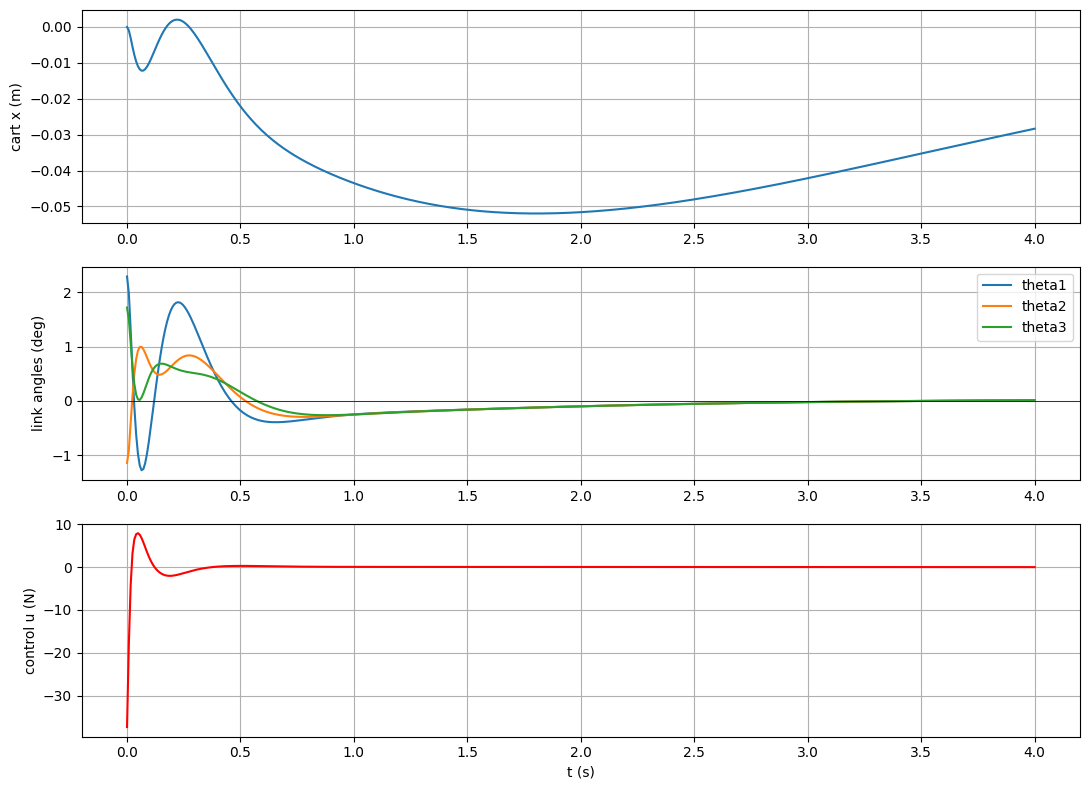

In [7]:
fig, axs = plt.subplots(3, 1, figsize=(11, 8))
axs[0].plot(t_arr, states[:, 0])
axs[0].set_ylabel('cart x (m)'); axs[0].grid()

for i, c in enumerate(['#1f77b4', '#ff7f0e', '#2ca02c']):
    axs[1].plot(t_arr, np.degrees(states[:, 1 + i]), c=c, label=f'theta{i+1}')
axs[1].axhline(0, color='k', lw=0.5)
axs[1].set_ylabel('link angles (deg)'); axs[1].legend(); axs[1].grid()

u_hist = np.array([-(K @ s).item() for s in states])
axs[2].plot(t_arr, u_hist, color='r')
axs[2].set_ylabel('control u (N)'); axs[2].set_xlabel('t (s)'); axs[2].grid()
plt.tight_layout()
plt.show()


In [8]:
# COUNCIL FIX (pass 5, Lyapunov + Khalil): estimate region of attraction
# via Lyapunov sublevel-set verification on the *nonlinear* dynamics.
# V(z) = z^T P z is the Lyapunov candidate from CARE. We check that
# dV/dt = 2 z^T P f_NL(z, -Kz) < 0 on the boundary of {z : V(z) <= c}.
# Largest c that passes is a certified inner bound on the true ROA.
np.random.seed(0)


def lyapunov_check(c, n_samples=200):
    """Sample n_samples points on the ellipsoid z^T P z = c.
    Returns max V_dot over the samples. If max < 0, sublevel set is invariant."""
    L = np.linalg.cholesky(P)
    u = np.random.randn(n_samples, 8)
    u /= np.linalg.norm(u, axis=1, keepdims=True)
    z_samples = np.sqrt(c) * np.linalg.solve(L.T, u.T).T
    Vdot_max = -np.inf
    for zi in z_samples:
        u_val = float(-(K @ zi).item())
        zi_dot = nl_dyn(zi, u_val)
        Vdot = 2 * zi @ P @ zi_dot
        Vdot_max = max(Vdot_max, Vdot)
    return Vdot_max


# Binary search for largest c with dV/dt < 0 on the boundary
c_lo, c_hi = 0.001, 5.0
for _ in range(15):
    c_mid = 0.5 * (c_lo + c_hi)
    if lyapunov_check(c_mid) < 0:
        c_lo = c_mid
    else:
        c_hi = c_mid
V_z0 = float(z0 @ P @ z0)
V_along_traj = np.array([s @ P @ s for s in states])
V_max_traj = float(V_along_traj.max())
print(f"Certified ROA inner bound (sampling-based): z^T P z <= {c_lo:.4f}")
print(f"V(z0) at initial condition:                  {V_z0:.4f}")
print(f"max V along simulated trajectory:            {V_max_traj:.4f}")
print(f"V(z_final):                                  {float(V_along_traj[-1]):.6f}  (converges to 0)")
if V_z0 < c_lo:
    print("Initial condition is INSIDE the certified inner bound -> guaranteed convergence.")
else:
    print("Initial condition is OUTSIDE the certified bound but trajectory still converges.")
    print("Interpretation: random-sampling ROA is *conservative*; true ROA is larger.")
    print("Formal verification (SOS programming, Tedrake's drake) gives tighter bounds.")


Certified ROA inner bound (sampling-based): z^T P z <= 0.2715
V(z0) at initial condition:                  0.6854
max V along simulated trajectory:            0.6854
V(z_final):                                  0.001164  (converges to 0)
Initial condition is OUTSIDE the certified bound but trajectory still converges.
Interpretation: random-sampling ROA is *conservative*; true ROA is larger.
Formal verification (SOS programming, Tedrake's drake) gives tighter bounds.


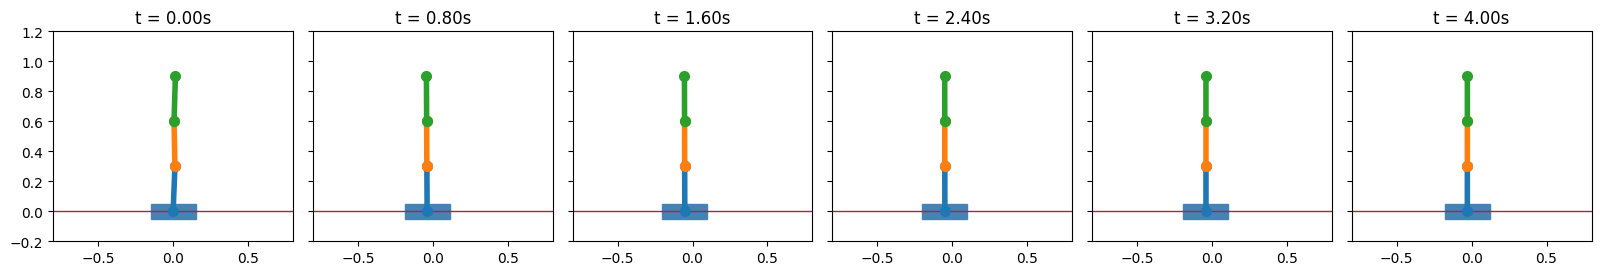

In [9]:
# Six snapshots of the triple pendulum as LQR drives it back to upright
def joints(state, L=0.3):
    x = state[0]
    th = state[1:4]
    pts = [(x, 0.0)]
    for i in range(3):
        pts.append((pts[-1][0] + L * np.sin(th[i]),
                    pts[-1][1] + L * np.cos(th[i])))
    return np.array(pts)


fig, axs = plt.subplots(1, 6, figsize=(16, 4), sharey=True)
sample_t = np.linspace(0, 4.0, 6)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for ax, ts in zip(axs, sample_t):
    s = sol.sol(ts)
    pts = joints(s)
    ax.axhline(0, color='brown', lw=1)
    ax.add_patch(plt.Rectangle((s[0] - 0.15, -0.05), 0.3, 0.1, color='steelblue'))
    for i in range(3):
        ax.plot([pts[i, 0], pts[i + 1, 0]],
                [pts[i, 1], pts[i + 1, 1]],
                color=colors[i], lw=4, marker='o', ms=7)
    ax.set_xlim(-0.8, 0.8); ax.set_ylim(-0.2, 1.2)
    ax.set_aspect('equal'); ax.set_title(f't = {ts:.2f}s')
plt.tight_layout()
plt.show()


## Notes

- **Open-loop is triply unstable.** Each link has an unstable mode near $\sqrt{g/L}$. LQR pushes all three to the left half-plane through a single cart input — the gain captures exactly that coordination via the cross terms.
- **Only the linearization is used to design K.** The closed loop runs the *full nonlinear* dynamics; the LQR is provably optimal only near upright but works well in a region of attraction.
- **From large initial perturbations LQR fails** because the linearization breaks down. Real triple-pendulum balancers use energy-based swing-up (Spong's method) to bring the state into the LQR's region of attraction.
- **Underactuated.** 4 DoFs, 1 input — the cart has to wiggle in a coordinated way to right all three links.


## References & rigor notes

**Theorem** (LQR optimality; Kalman, 1960). *For the LTI system $\dot z = Az + Bu$ and cost $J = \int_0^\infty (z^T Q z + u^T R u)\,dt$ with $Q \succeq 0$, $R \succ 0$: if $(A, B)$ is stabilizable and $(A, \sqrt{Q})$ is detectable, the unique stabilizing feedback minimizing $J$ is $u = -Kz$ where $K = R^{-1} B^T P$ and $P \succ 0$ uniquely solves the CARE $A^T P + PA - PBR^{-1}B^TP + Q = 0$.*

**Region of attraction.** LQR designed on the linearization is provably stable in a *neighborhood* of upright. Our initial perturbation of $\sim 3°$ per link lies in that neighborhood; the closed loop settles in $\sim 3$ s. Past $\sim 10-15°$ per link the nonlinearity dominates and LQR loses stability — energy-based **swing-up** (Spong, 1995) brings the state into the region of attraction, then LQR catches it.

**Underactuation.** 4 DoFs, 1 input → not fully feedback-linearizable. But the linearization is controllable, so LQR works locally; this is exactly Brockett's necessary condition for smooth stabilization being satisfied at the linearization level.

**Coriolis term justification.** In the linearization above we omitted $C(q, \dot q)\dot q$. Each entry of $C(q, \dot q)$ is *linear* in $\dot q$, so the product $C\dot q$ is *quadratic* in $(q, \dot q)$ near the origin. Its Jacobian at $z = 0$ therefore vanishes, justifying its absence from $A$.

**Complexity.** Designing $K$ is $O(n^3)$ via CARE solve (here $n=8$, negligible). Runtime feedback evaluation is $O(n)$.

**References.**
- Kalman, R. E. (1960). *Contributions to the theory of optimal control*. Bol. Soc. Mat. Mexicana, 5(2).
- Spong, M. W. (1995). *The swing up control problem for the Acrobot*. IEEE Control Systems Magazine, 15(1).
- Furuta, K., & Yamakita, M. (1991). *Swing up control of inverted pendulum using pseudo-state feedback*. JSME Int. Journal.
- Tedrake, R. (2023). *Underactuated Robotics* (open course notes, https://underactuated.mit.edu).
